# HR Analytics & Employee Attrition Analysis

## 02 - Exploratory Data Analysis (EDA)

This notebook explores employee demographics, job characteristics,
income, tenure, satisfaction, and attrition patterns.

### Objectives
- Understand the employee population
- Analyze the distribution of key numerical variables
- Analyze categorical variables
- Compare employees who stayed vs. employees who left
- Identify patterns associated with employee attrition
- Create visualizations for the Power BI and reporting stages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset

In [2]:
df = pd.read_csv("../data/cleaned/HR_Python_Cleaned_Data.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Income_Group,Tenure_Group,Age_Group
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,8,0,1,6,4,0,5,Medium,6-10 Years,35-44
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,10,3,3,10,7,1,7,Medium,6-10 Years,45-54
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,7,3,3,0,0,0,0,Low,0-1 Years,35-44
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,8,3,3,8,7,3,0,Low,6-10 Years,25-34
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,6,3,3,2,2,2,2,Medium,2-5 Years,25-34


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   1470 non-null   str  
 15

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 2. Overall Attrition

In [6]:
attrition_counts = df["Attrition"].value_counts()

attrition_counts

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
attrition_percent = df["Attrition"].value_counts(normalize=True) * 100

attrition_percent.round(2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

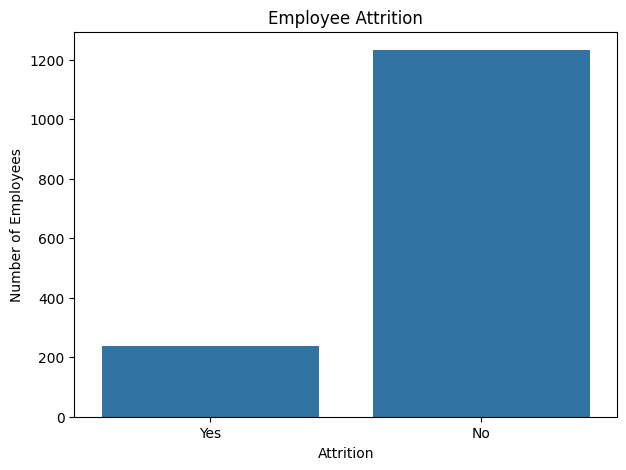

In [55]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.savefig(
    "../images/attrition_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Employee Age Analysis

In [10]:
df["Age"].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

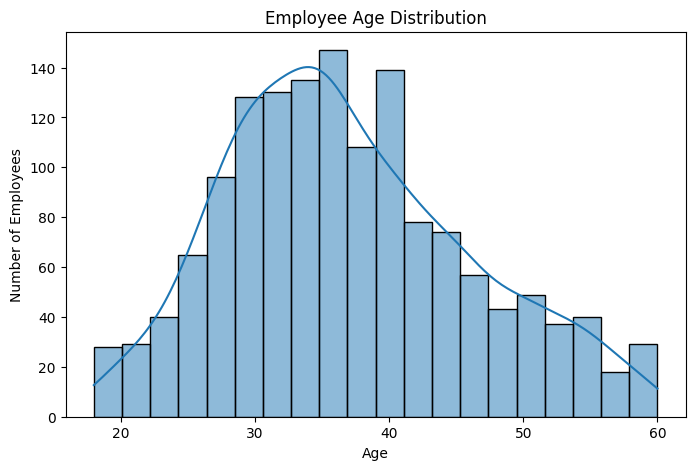

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

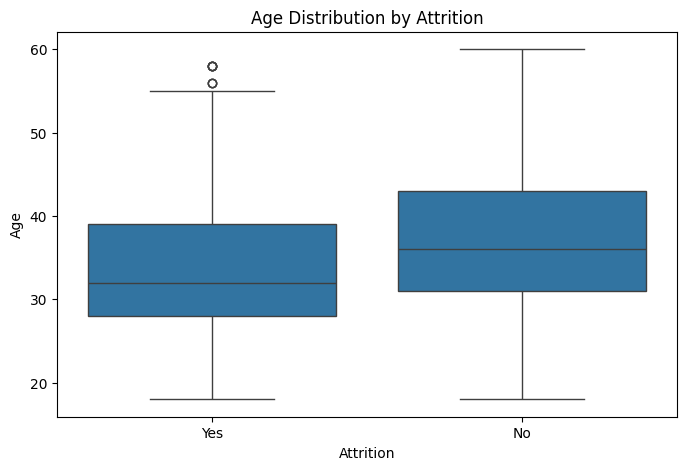

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Attrition", y="Age")

plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.savefig(
    "../images/attrition_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
df.groupby("Attrition")["Age"].mean().round(2)

Attrition
No     37.56
Yes    33.61
Name: Age, dtype: float64

In [14]:
age_attrition = pd.crosstab(
    df["Age_Group"],
    df["Attrition"]
)

age_attrition

Attrition,No,Yes
Age_Group,,
25-34,442,112
35-44,454,51
45-54,220,25
55+,58,11
Under 25,59,38


In [15]:
age_attrition_rate = (
    df.groupby("Age_Group")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

age_attrition_rate

Age_Group
25-34       20.22
35-44       10.10
45-54       10.20
55+         15.94
Under 25    39.18
Name: Attrition, dtype: float64

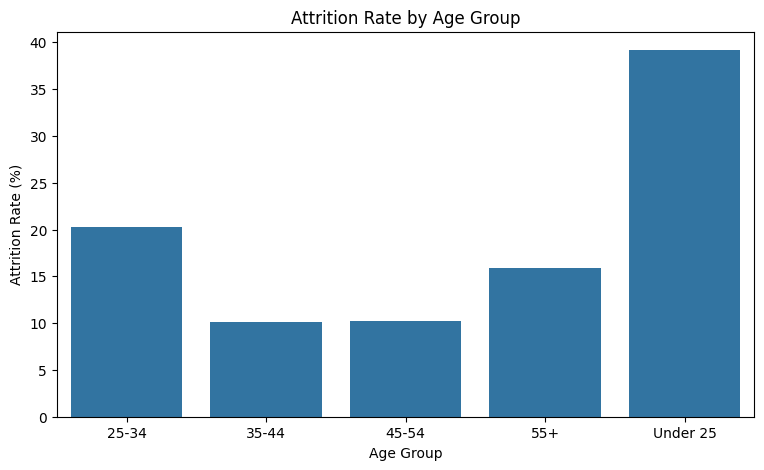

In [56]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_attrition_rate.index,
    y=age_attrition_rate.values
)

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.savefig(
    "../images/attrition_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Department Analysis

In [17]:
department_counts = df["Department"].value_counts()

department_counts

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

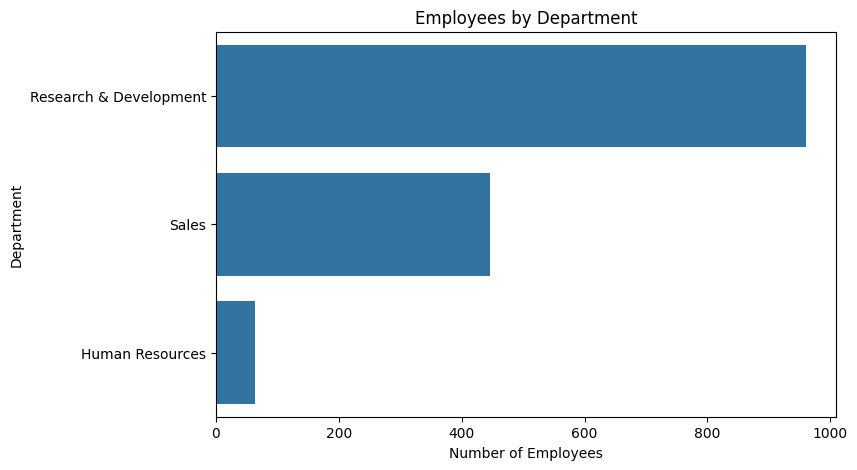

In [59]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    y="Department",
    order=df["Department"].value_counts().index
)

plt.title("Employees by Department")
plt.xlabel("Number of Employees")
plt.ylabel("Department")

plt.savefig(
    "../images/attrition_by_department.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)

department_attrition

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

In [22]:
department_summary = (
    df.groupby("Department")
      .agg(
          Employees=("EmployeeNumber", "count"),
          Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
          Attrition_Rate=("Attrition", lambda x: (x == "Yes").mean() * 100)
      )
      .round(2)
)

department_summary

,Employees,Employees_Left,Attrition_Rate
Department,,,
Human Resources,63,12,19.05
Research & Development,961,133,13.84
Sales,446,92,20.63


## 5. Job Role Analysis

In [20]:
jobrole_counts = df["JobRole"].value_counts()

jobrole_counts

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

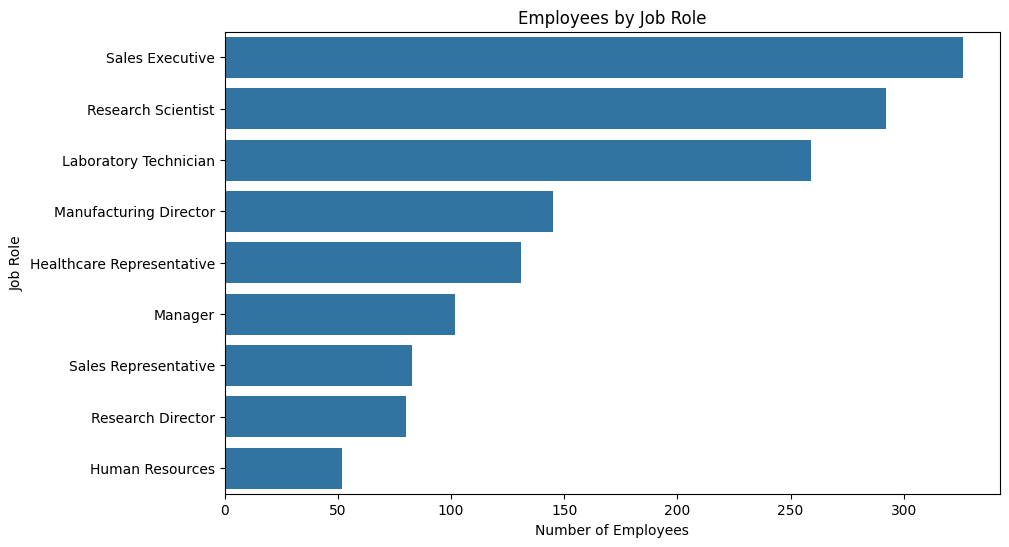

In [60]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="JobRole",
    order=df["JobRole"].value_counts().index
)

plt.title("Employees by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.savefig(
    "../images/attrition_by_job_role.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)

jobrole_attrition

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

## 6. Overtime Analysis

In [29]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

overtime_attrition

OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64

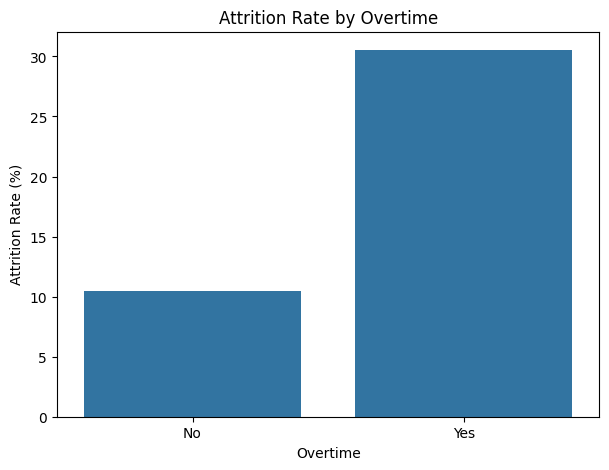

In [57]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=overtime_attrition.index,
    y=overtime_attrition.values
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "../images/attrition_by_overtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Tenure Analysis

In [26]:
tenure_attrition = (
    df.groupby("Tenure_Group")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

tenure_attrition

Tenure_Group
0-1 Years     34.88
10+ Years      8.13
2-5 Years     15.51
6-10 Years    12.28
Name: Attrition, dtype: float64

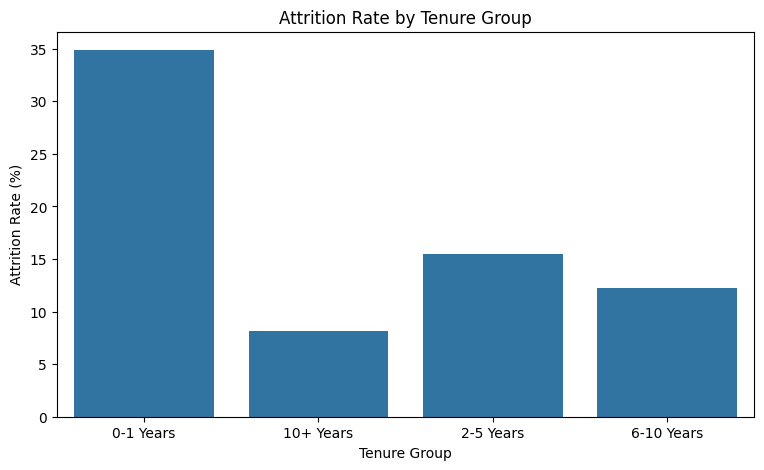

In [58]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_attrition.index,
    y=tenure_attrition.values
)

plt.title("Attrition Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "../images/attrition_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Income Analysis

In [28]:
df["MonthlyIncome"].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

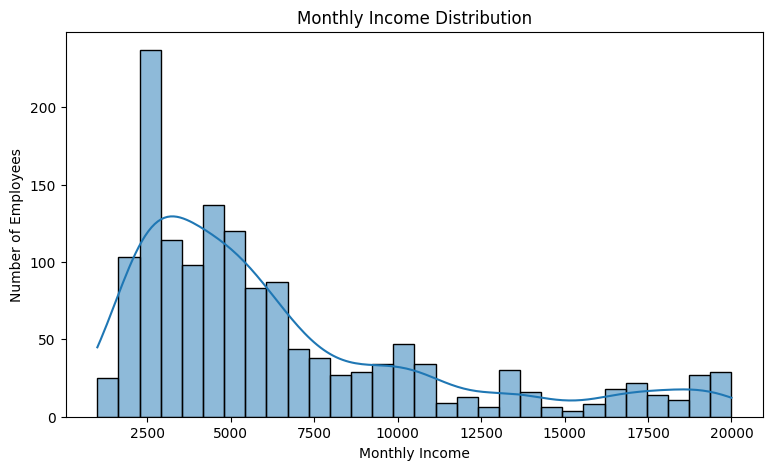

In [29]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.show()

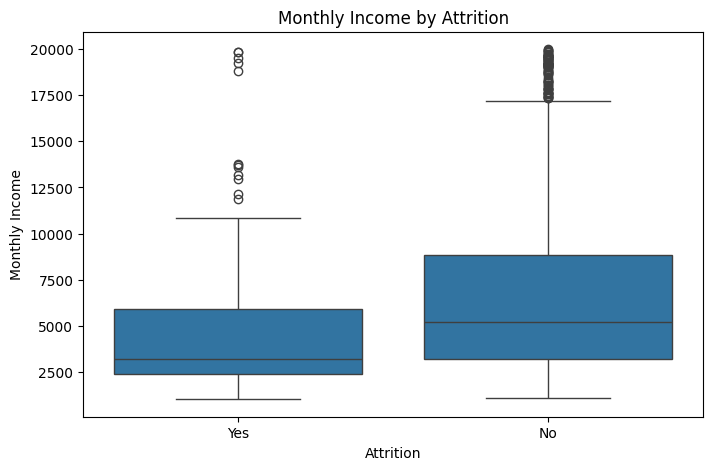

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.savefig(
    "../images/attrition_by_income.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [31]:
df.groupby("Attrition")["MonthlyIncome"].mean().round(2)

Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64

## 9. Job Satisfaction

In [34]:
job_satisfaction = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"]
)

job_satisfaction

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [19]:
satisfaction_attrition = (
    df.groupby("JobSatisfaction")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

satisfaction_attrition

JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: Attrition, dtype: float64

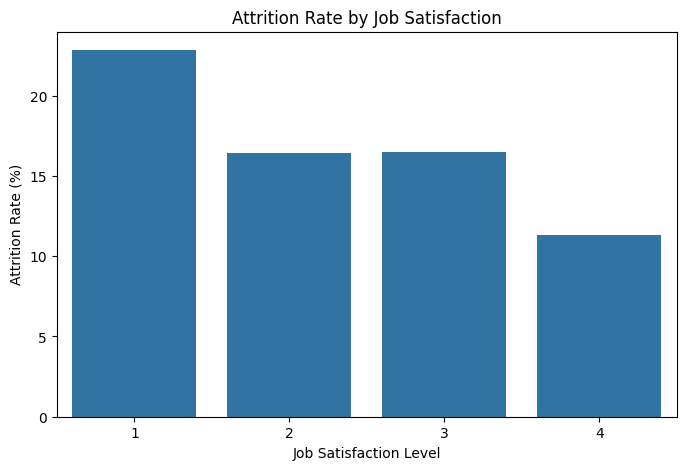

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=satisfaction_attrition.index,
    y=satisfaction_attrition.values
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "../images/attrition_by_job_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 10. Work-life balance

In [17]:
worklife_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

worklife_attrition

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64

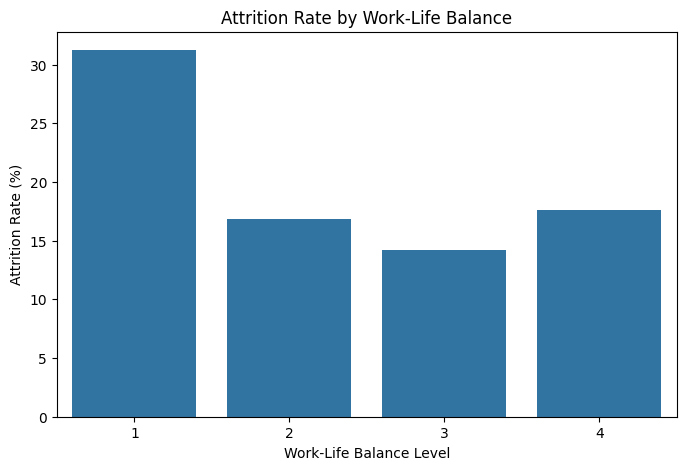

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=worklife_attrition.index,
    y=worklife_attrition.values
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "../images/attrition_by_worklife_balance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 11. Business travel

In [15]:
travel_attrition = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)

travel_attrition

BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64

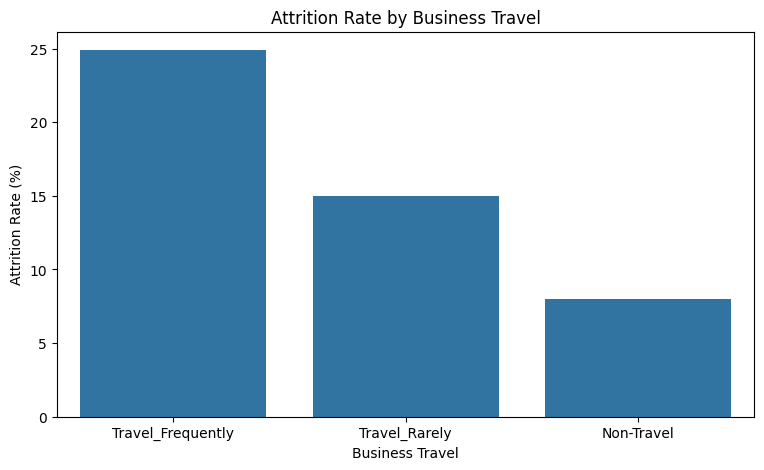

In [16]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=travel_attrition.index,
    y=travel_attrition.values
)

plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "../images/attrition_by_business_travel.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 12. Gender analysis

In [13]:
gender_attrition = (
    df.groupby("Gender")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

gender_attrition

Gender
Female    14.80
Male      17.01
Name: Attrition, dtype: float64

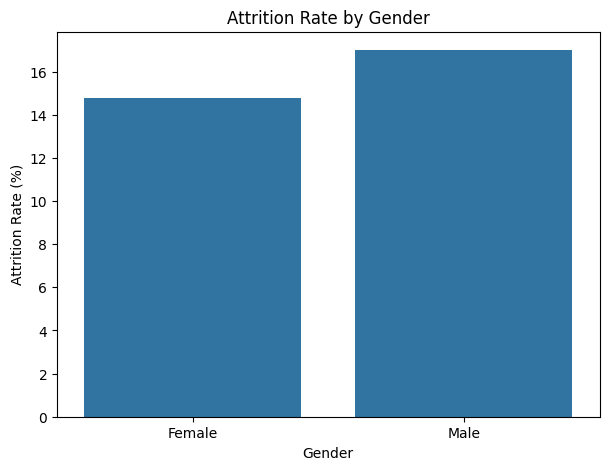

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_attrition.index,
    y=gender_attrition.values
)

plt.title("Attrition Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "../images/attrition_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 13. Correlation analysis

In [8]:
numeric_df = df.select_dtypes(include=np.number)

In [9]:
correlation_matrix = numeric_df.corr()

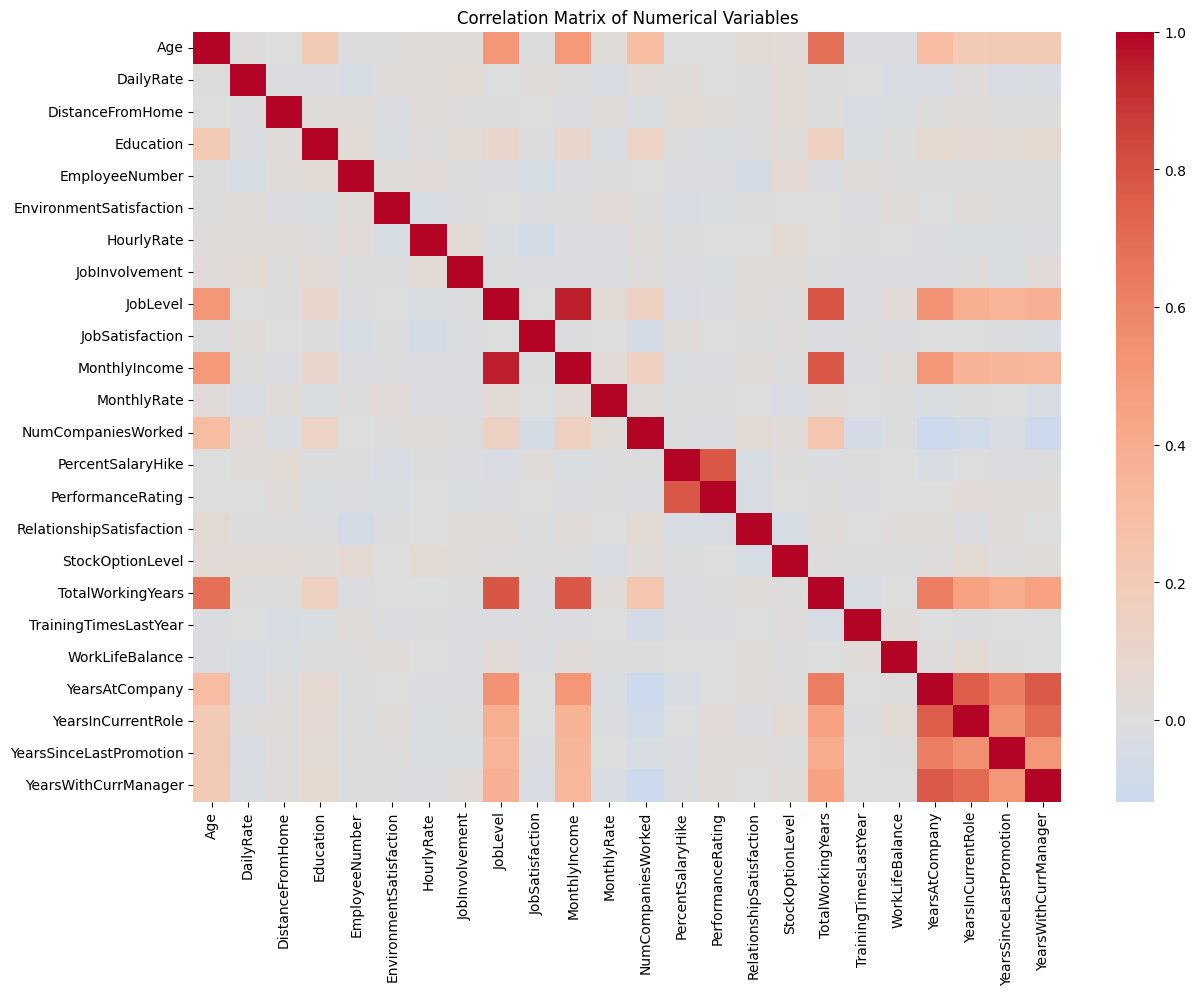

In [11]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.savefig(
    "../images/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Key EDA Findings

In [30]:
print("Overall Attrition Rate:")
print(f"{(df['Attrition'] == 'Yes').mean() * 100:.2f}%")

print("\nAttrition by Department:")
print(department_attrition)

print("\nAttrition by Job Role:")
print(jobrole_attrition)

print("\nAttrition by Overtime:")
print(overtime_attrition)

print("\nAttrition by Tenure:")
print(tenure_attrition)

Overall Attrition Rate:
16.12%

Attrition by Department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

Attrition by Job Role:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

Attrition by Overtime:
OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64

Attrition by Tenure:
Tenure_Group
0-1 Years     34.88
10+ Years      8.13
2-5 Years     15.51
6-10 Years    12.28
Name: Attrition, dtype: float64


## Attrition-focused summary table

In [49]:
attrition_summary = pd.DataFrame({
    "Total Employees": df.groupby("Attrition").size(),
    "Average Age": df.groupby("Attrition")["Age"].mean(),
    "Average Monthly Income": df.groupby("Attrition")["MonthlyIncome"].mean(),
    "Average Years at Company": df.groupby("Attrition")["YearsAtCompany"].mean(),
    "Average Job Satisfaction": df.groupby("Attrition")["JobSatisfaction"].mean(),
    "Average Work-Life Balance": df.groupby("Attrition")["WorkLifeBalance"].mean()
})

attrition_summary.round(2)

,Total Employees,Average Age,Average Monthly Income,Average Years at Company,Average Job Satisfaction,Average Work-Life Balance
Attrition,,,,,,
No,1233,37.56,6832.74,7.37,2.78,2.78
Yes,237,33.61,4787.09,5.13,2.47,2.66
